# Results in progress

Here results that are obtained during the simulations will be documented

## First simulation
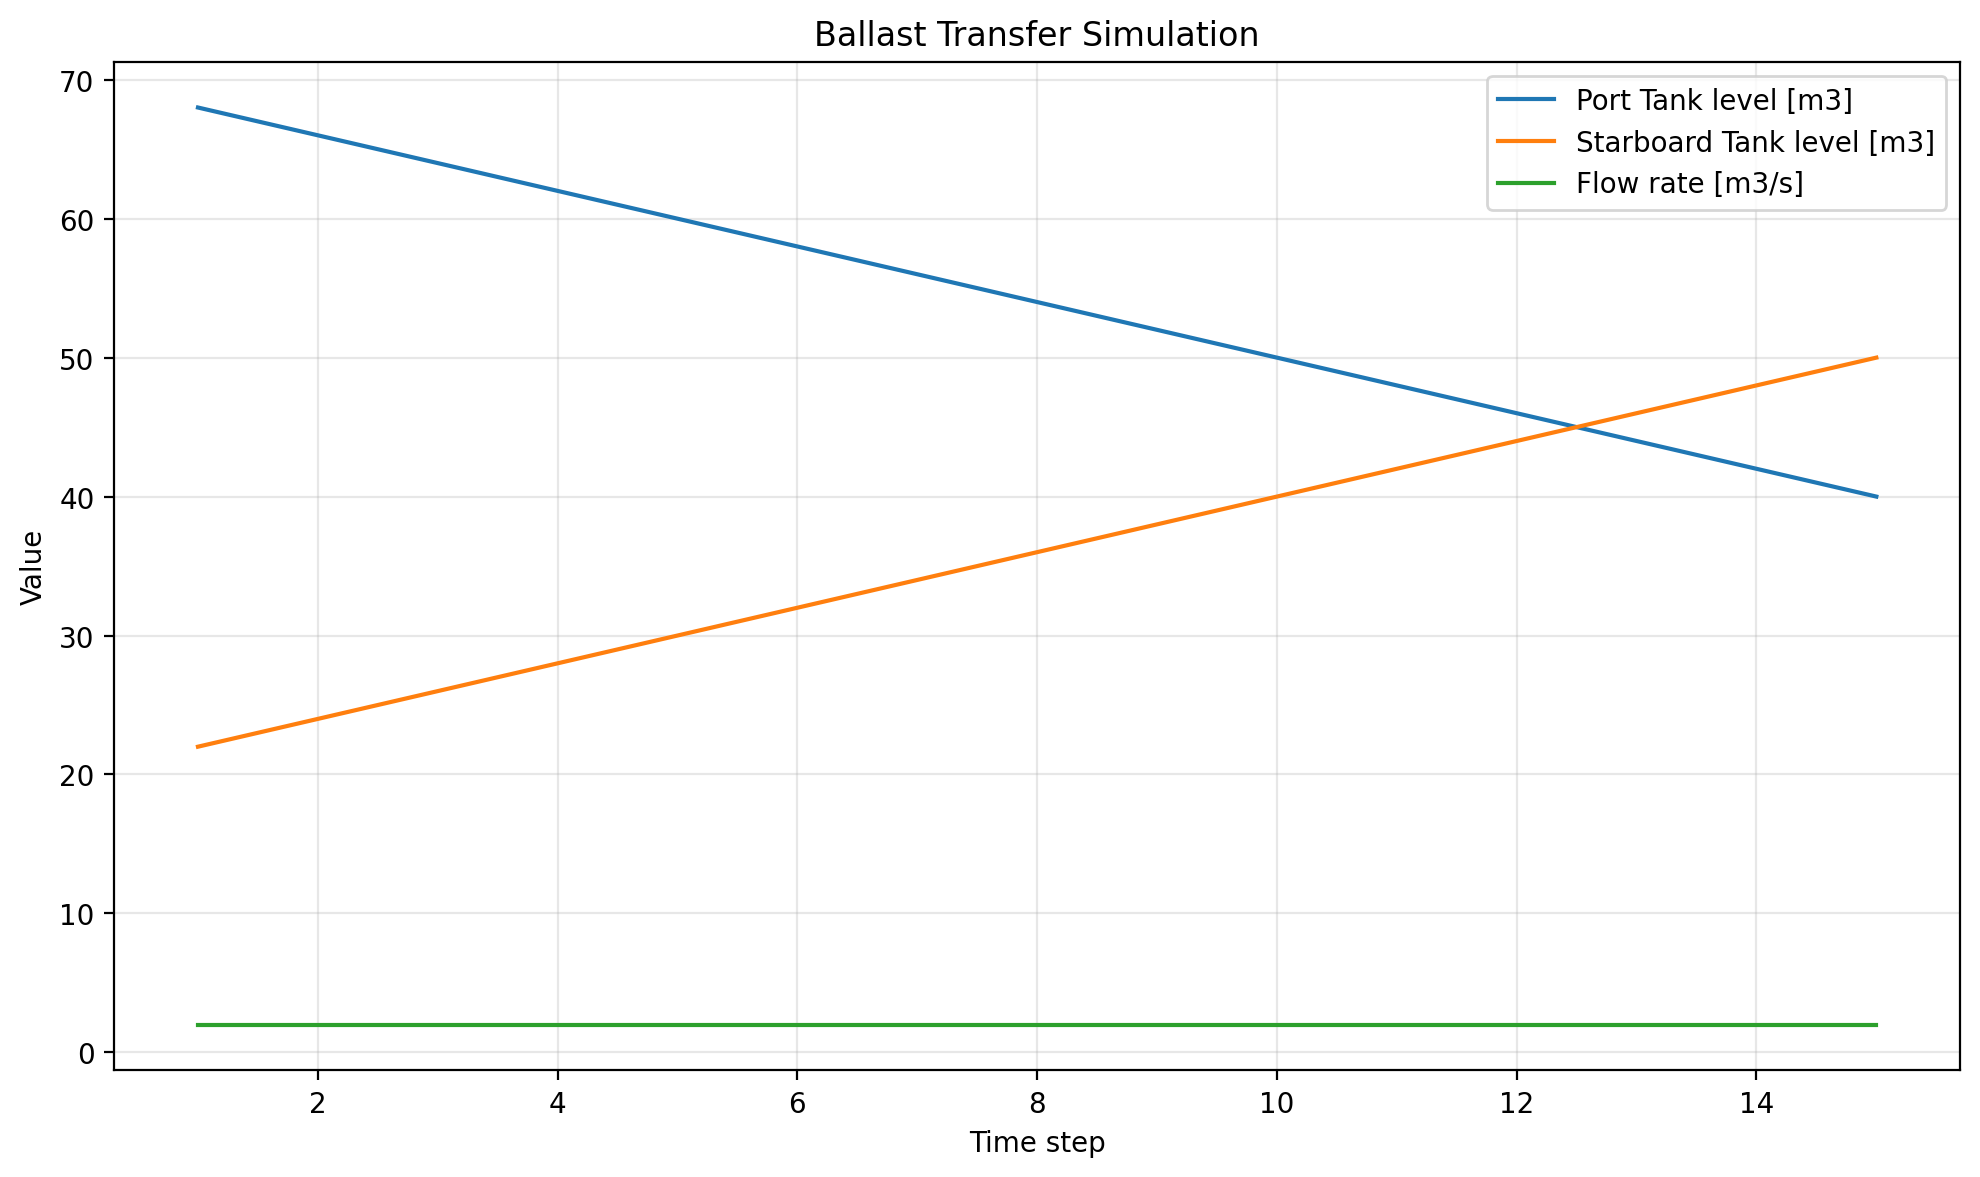

Here can be seen:
- Port tank goes down linearly
- Starboard tank goes up linearly
- Flow stays constant

So the core transfer logic is working

But also: this plot is still a bit too simple to feel like “automation.” Right now it’s mostly a basic process simulation. The next step is to make it behave like a control system.

At the moment:

- pump is just on
- both valves are just open
- transfer continues with no decisions
- nothing reacts to limits or faults

That is why the curves are straight.

## Run after adding some limits  
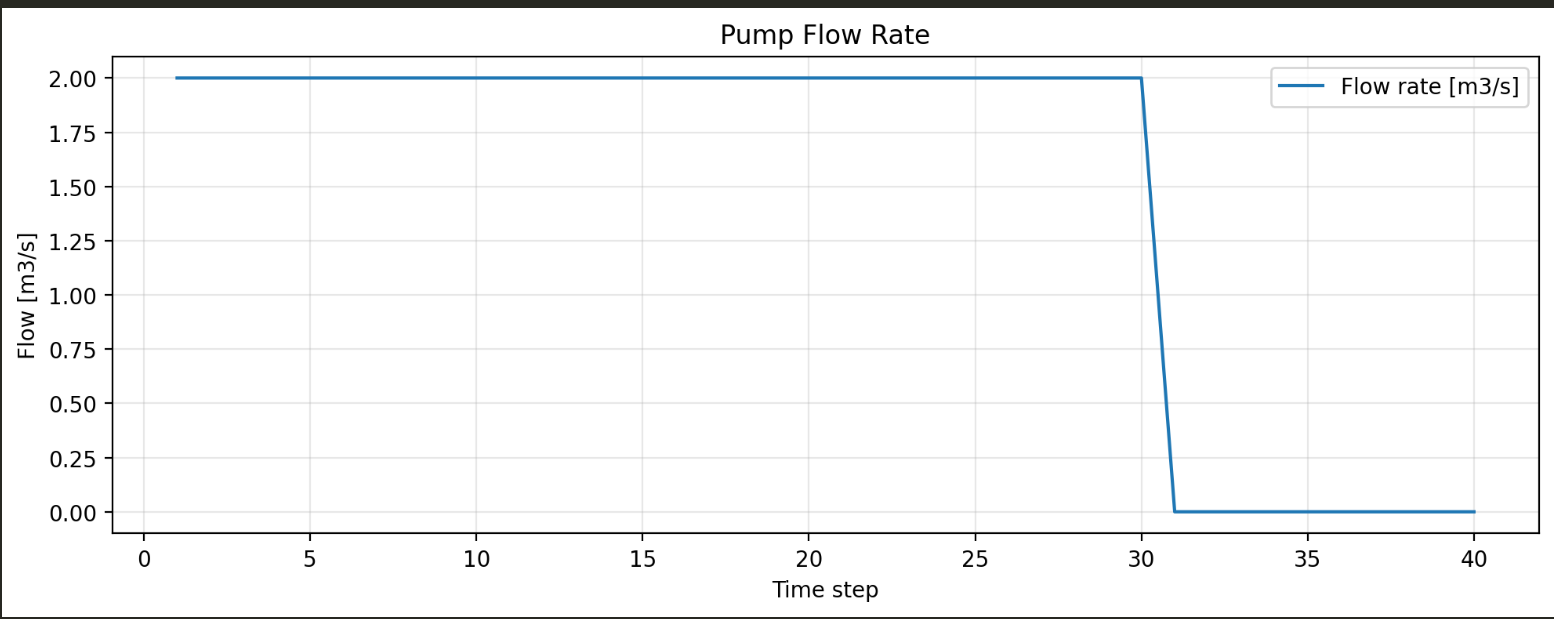

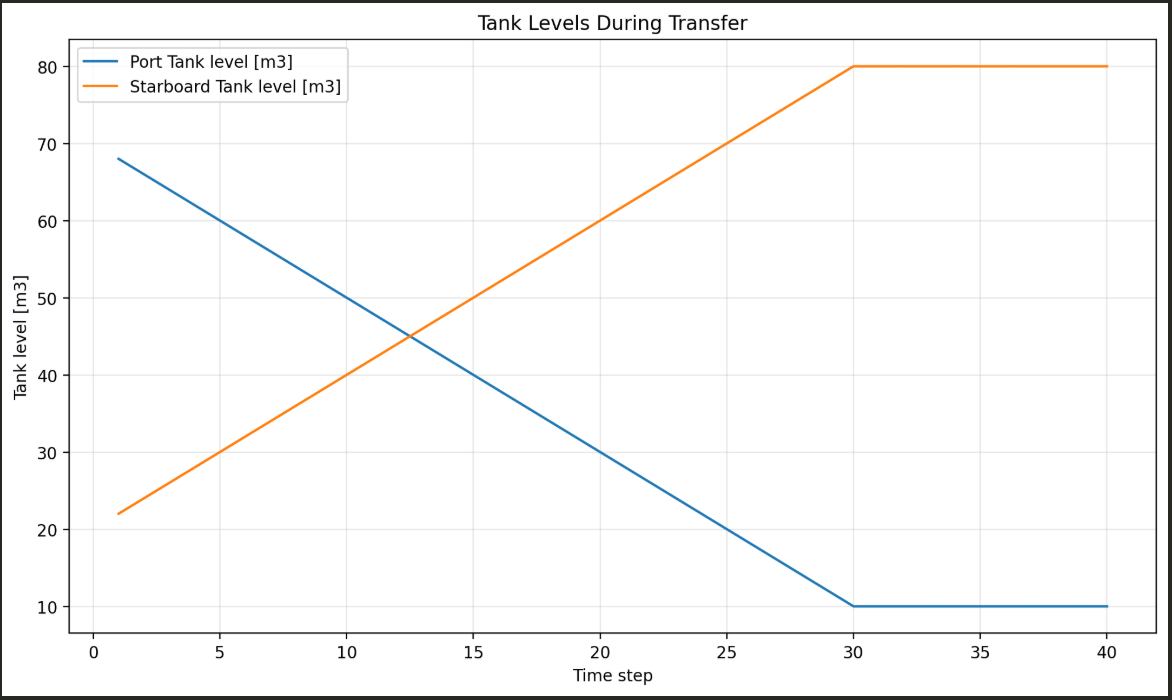

### How to read plots
**Tank level plots**
- **Port tank** starts around 68 and decreases linearly
- **Starboard tank** starts around 22 and increases linearly
- both stop changing once **starboard reaches 60**
- So:
    - Transfer is active until target reached
    - After that, auto logic stops pump
    - System remain stable
    - Flat section after ~30 is exactly desired

**Flow plot**
- Flow stays at 2 m3/s
- Then drops to 0 sharply
- Remains 0 afterwards
- Meaning that:
    - Transfer was allowed and commanded initially
    - Later the pump was no longer commanded ON
    - No flow occurs after target is reached
- So this stop is now caused by control logic.

### What is happening in this run
1. Auto logic is active
- In logic.py we set target for destination tank:
    - Starboard tank target = 60m3
- So before each simulation step, control layer checks:
    - Is destination tank below 60m3?
        - Yes: Command pump ON
    - Has destination tank reached 60m3?
        - Yes: Command pump OFF
- So process stops around 20 steps in instead of continuing

2. Interlocks are still guarding process
- Even if logic wants the pump ON, interlocks.py still decides whether transfer is allowed.
- Right now interlocks check things like:
    - pump status
    - suction valve open
    - discharge valve open
    - source tank above low-low limit
    - destination tank below high-high limit

- So structure is:
    - Logic asks for transfer
    - Interlocks verify it is safe
    - System executes flow

3. Physical process still behaves simply
- Inside system.py, if transfer is allowed:
    - Pump provides requested flow
    - Source tank loses volume
    - Destination tank gains volume
    - Levels update step by step
- Since flow is constant, level curves are still straight lines during active transfer

### What changed conceptually after refactor
- Before, the project was mostly:
    - Pump ON + Valves OPEN: liquid moves until protection stops it
- Now, it is:
    - Control logic decides operating intent
    - Interlocks check safety/permissives
    - System performs the process

**Current architecture**
1. *main.py*
- Runs scenario:
    - Sets up equipment
    - Choose mode
    - Stores histories
    - Makes plots

2. *logic.py*
- Decides:
    - Should the pump be commanded ON or OFF
- Right now:
    - Manual mode = user command
    - Auto mode = maintain destination target level

3. *interlocks.py*
- Protects the process:
    - Blocks transfer if unsafe or impossible

4. *system.py*
- Simulates:
    - Flow calculation
    - Tank updates
    - Alarm flag updates
    - Status reporting

## V3 Scenario testing
Scenario tested:
- Transfer starts normally in manual mode
- Operator closes discharge valve during operation
- Flow drops to zero because interlock block transfer
- Operator notices issue and reopens valve
- Flow resumes

Demonstrates:
- Manual control
- Interlocks still active in manual mode
- Recovery after operation correction

### Results 
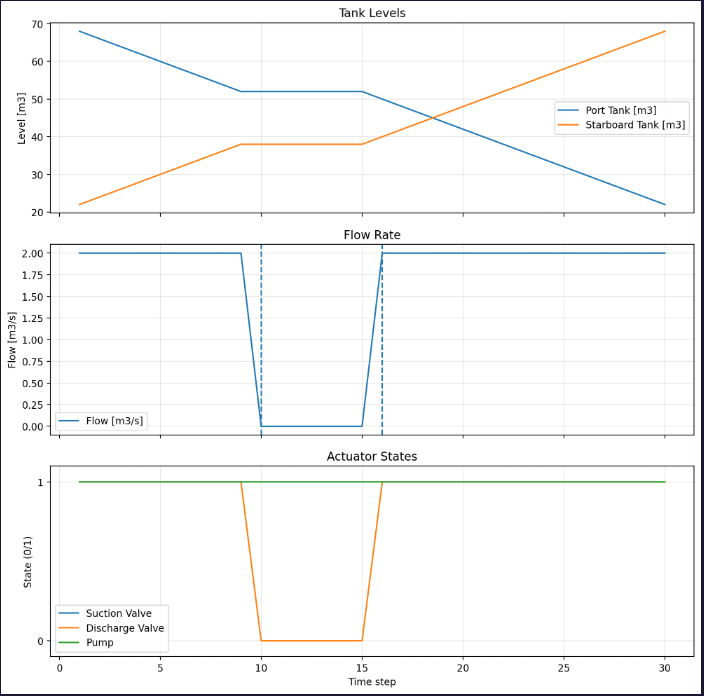

- Steps 1-9: normal transfer
    - both valves open
    - pump on
    - flow 2 m3/s
    - port tank decreases, starboard tank increases

- Steps 10-15: operator closes discharge valve
    - pump still commanded on
    - discharge valve closed
    - interlock blocks transfer
    - flow drops to 0
    - tank levels stay constant

- Steps 16-30: operator reopens discharge valve
    - valid flow path restored
    - flow resumes to 2 m3/s
    - tank levels continue changing


## Adding sequencing into the project

**Proposed states**
- IDLE
- OPENING_VALVES
- TRANSFERING
- STOPPING

1. IDLE
- System is not transfering:
    - Pump: OFF
    - Valves: CLOSED
- Transition out
    - If transfer is requested: go to OPENING_VALVES

2. OPENING_VALVES
- System prepares the flow path:
    - Suction valve: OPEN
    - Discharge valve: OPEN
    - Pump: OFF
- Transition out
    - If both valves are open: go to TRANSFERING
    - This gives sequence of: lineup first, then pump

3. TRANSFERING
- Normal transfer state:
    - Valves: OPEN
    - Pump: ON
- Transition out:
    - If transfer is no longer needed: go to STOPPING
    - Also if operator closes a valve manually in manual-mode testing, interlocks will block flow even if state still says TRANSFERING.

4. STOPPING
- Shut down sequence:
    - Pump: OFF
    - Valves: CLOSED
- Transition out:
    - When both valves are closed, go to IDLE
    - This gives stop pump first, then isolate 
    
### Results
- Plots state the same
- System outputs:
    - Step 1:
        - Pump is OFF
        - Sequence -> OPENING_VALVES
    - Meaning:
        - System starts in IDLE
        - Manual transfer is requested
        - Sequence moves into valve line-up
        - Pump is still off at this point
    - Step 2:
        - Sequence -> TRANSFERING
    - Meaning:
        - Valves confirmed open
        - System is ready to move from line-up to active transfer
    - Step 3:
        - Sequence -> TRANSFER ALLOWED
    - Meaning:
        - Pump is on
        - Valves are open
        - Interlocks allow flow
        - Actual transfer begins
    - Step 10:
        - Discharge valve is CLOSED
    - Meaning:
        - Operator action broke flow path
        - Interlock detected unsafe condition
        - Transfer blocked
    - Step 16:
        - Transfer allowed
    - Meaning:
        - Operator reopened discharge valve
        - Path restored
        - Interlock cleared
        - Transfer resumed
        
        

## V4: Command vs actual state introduction

Since for now, system trusted only command input and not actual state of the element. I introduce this extension.

It should:
- Check actual state
- React if mismatch happens
- Trigger alarms/interlocks

**Architecture after update**

1. *logic.py*

sets:
- desired valve state
- desired pump state

replaced direct .open()/closed() calls with:
- set_command(True/False)

2. *valve.py*

converts:
- command → actual state
- unless fault prevents movement

added:
- commanded_open
- is_open
- stuck_closed
- update()

3. *system.py*

uses:
- actual valve state
- actual pump state
- to compute transfer

At the beginning of step():
- update both valves from command to actual

### Results
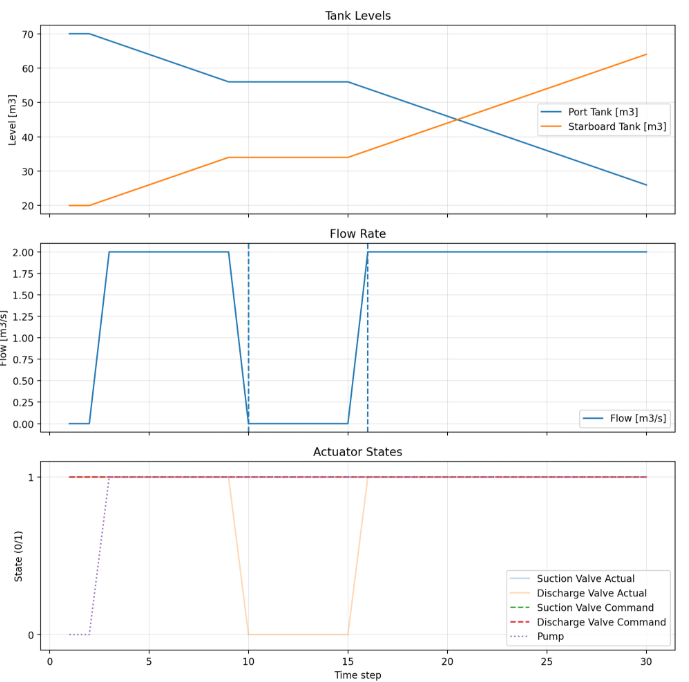

Here can be seen expected discrepancy, at steps 10-16.
- Discharge valve command stays at 1
- Discharge valve actual drops to 0
- Correct thing happens to the flow, since valve is closed, flow also drops to 0

### Added same logic for pump
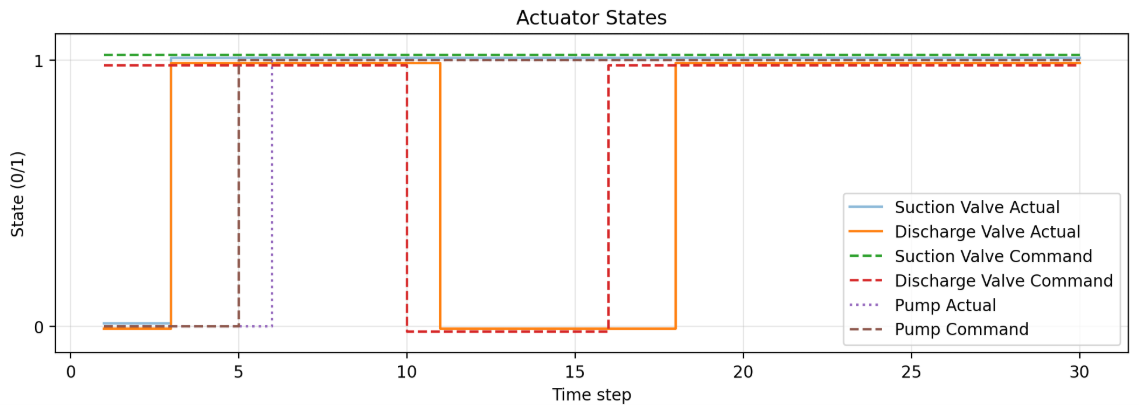

Here can be seen a clear difference and delays for each of system elements.
- Corrected bug where no delay happened for accident of valve closing, that there was no command state follow and no delay in actual state